#  Titanic Data Analysis

##  Objective
The goal of this project is to analyze the Titanic dataset and identify key factors that influenced passenger survival.

We will:
- Understand the dataset
- Clean missing data
- Visualize patterns
- Extract meaningful insights

## Import Libraries

We import essential libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

##  Load Dataset

We load the Titanic dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## DATA UNDERSTANDING
We explore the structure of the dataset.
#### **df.shape** 👉 The dataset contains 
- 891 (*rows = passengers*)
- 12 (*columns = features*).
#### **df.info()** 👉 This shows:
- Data types (int, float, object)
- Missing values
#### **df.isnull().sum()** 👉 Missing values are found in:
- Age
- Cabin
- Embarked

In [14]:
df.shape

(891, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.2+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

We handle missing values to make the dataset usable.
- **Filling Missing Age Values**
We replace missing Age values with the **mean (average)**.
- **Dropping Cabin Column**
The Cabin column has too many missing values, so we remove it.
- **Filling Missing Embarked Values**
We use the **mode (most frequent value)** for categorical data.

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df.drop("Cabin", axis=1, inplace=True)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 📊 Data Visualization

We visualize patterns to understand survival trends.

### Survival Count

This shows how many passengers survived vs did not survive.

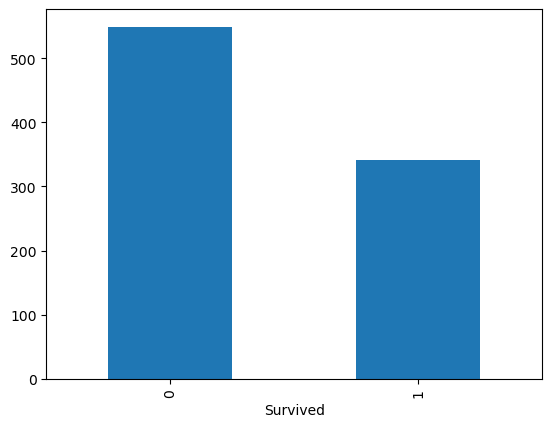

In [9]:
df["Survived"].value_counts().plot(kind="bar")
plt.savefig("../images/survival.png")
plt.show()

### Survival Rate by Gender

This shows survival probability for males and females.

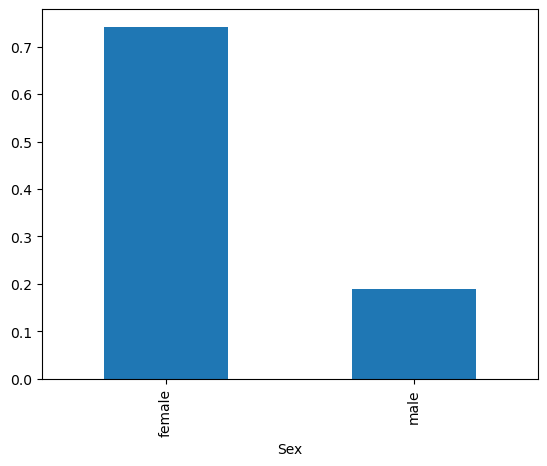

In [10]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.savefig("../images/gender_survival.png")
plt.show()

### Survival Rate by Passenger Class

We analyze survival based on ticket class (1st, 2nd, 3rd).

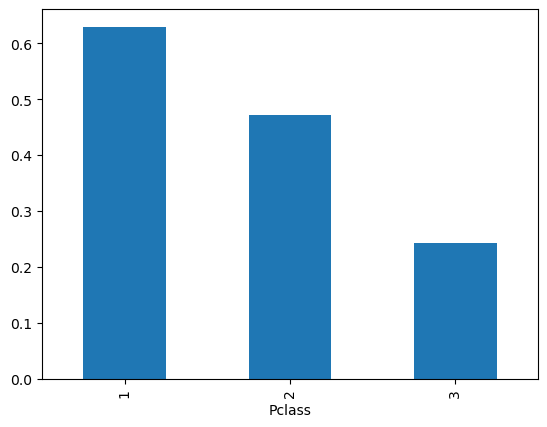

In [12]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.savefig("../images/class_survival.png")
plt.show()

### Age Distribution

This shows how passenger ages are distributed.

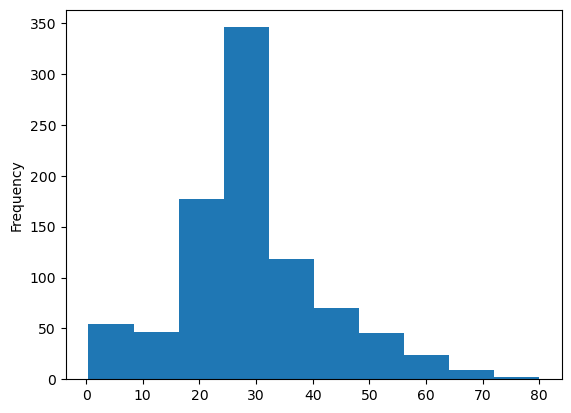

In [13]:
df["Age"].plot(kind="hist")
plt.savefig("../images/age.png")
plt.show()

## 🔍 Key Insights

From the analysis:

- Females had a higher survival rate than males
- First-class passengers had better survival chances
- Most passengers were in lower classes
- Age distribution shows many young passengers

These insights indicate that gender and class played a major role in survival.

In [17]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
